In [1]:
from tinyphysics import TinyPhysicsModel, TinyPhysicsSimulator, CONTROL_START_IDX
from controllers import pid, zero, pid_v2, pid_ref
from matplotlib import pyplot as plt
import seaborn as sns

sns.set_theme()


/home/gregor/.pyenv/versions/3.10.14/envs/controls/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_rollout(sim:TinyPhysicsSimulator):
  fig, ax = plt.subplots(figsize=(10, 5))
  ax.plot(sim.target_lataccel_history, label="Target Lateral Acceleration", alpha=0.5)
  ax.plot(sim.current_lataccel_history, label="Actual Lateral Acceleration", alpha=0.5)
  ax.legend()
  ax.set_xlabel("Step")
  ax.set_ylabel("Lateral Acceleration")
  ax.set_title("Rollout")
  plt.show()

{'lataccel_cost': 2.4264364362959068, 'jerk_cost': 29.07331298311584, 'total_cost': 150.39513479791117}


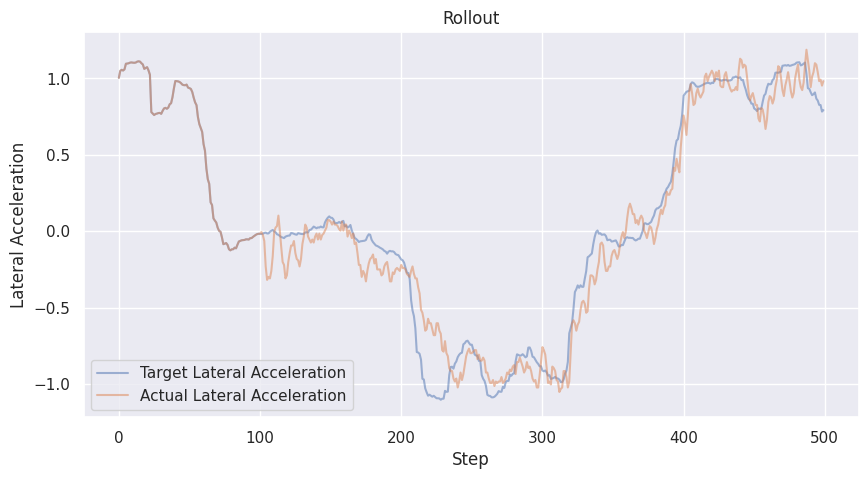

In [5]:
import importlib
importlib.reload(pid_v2)
controller = pid_v2.Controller()
# controller = pid_ref.Controller()
sim = TinyPhysicsSimulator("./data/00000.csv", controller=controller, debug=False)
print(sim.rollout())
plot_rollout(sim)